# Viral Cooking Trends on YouTube
## Time Series Analysis of Rise, Peak, and Decay Patterns

In [16]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [17]:
import os
os.chdir('..')  # move up from notebooks/ to project root
print(os.getcwd())  # confirm it shows your project root

c:\Users\glori\Documents\GlosResources\DE\Technische Hochschule Aschaffenburg\semester 3\Data Science Foundations of AI\feb-mar 2026 projects\data-science-portfolio


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.visualize import TrendVisualizer
from src.features import FeatureEngineer
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [23]:
# Load data. Notebook should only read processed CSVs.
daily_df = pd.read_csv('Time Series Analysis of Youtube Food Virality/data/processed/daily_views_exponential.csv')
daily_df['date'] = pd.to_datetime(daily_df['date'])
peaks_df = pd.read_csv('Time Series Analysis of Youtube Food Virality/data/processed/peak_analysis.csv')
peaks_df['peak_date'] = pd.to_datetime(peaks_df['peak_date'])
raw_df = pd.read_csv('Time Series Analysis of Youtube Food Virality/data/raw/all_trends_complete.csv')
features_df = pd.read_csv('Time Series Analysis of Youtube Food Virality/data/processed/trend_features.csv')

daily_df = daily_df.sort_values(['trend_name', 'date'])
daily_df['views_velocity'] = daily_df.groupby('trend_name')['views'].diff()

## 1. Overview: How Long Do Viral Trends Last?

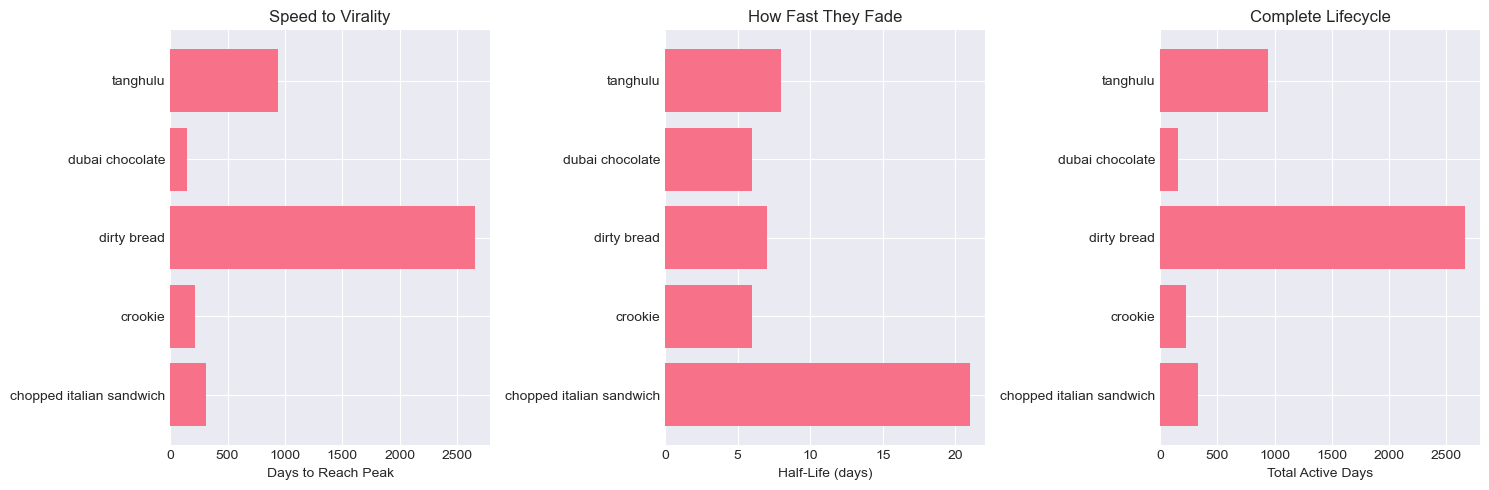

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Days to peak
axes[0].barh(features_df['trend_name'], features_df['days_to_peak'])
axes[0].set_xlabel('Days to Reach Peak')
axes[0].set_title('Speed to Virality')

# Half-life
axes[1].barh(features_df['trend_name'], features_df['half_life_days'])
axes[1].set_xlabel('Half-Life (days)')
axes[1].set_title('How Fast They Fade')

# Total lifespan
total_lifespan = features_df['days_to_peak'] + features_df['half_life_days'].fillna(60)
axes[2].barh(features_df['trend_name'], total_lifespan)
axes[2].set_xlabel('Total Active Days')
axes[2].set_title('Complete Lifecycle')

plt.tight_layout()
plt.savefig('Time Series Analysis of Youtube Food Virality/data/figures/lifespan_summary.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Trend Shape Classification

In [26]:
# Create shape summary
shape_summary = features_df.groupby('shape_classification').agg({
    'trend_name': 'count',
    'peak_intensity': 'mean',
    'days_to_peak': 'mean',
    'half_life_days': 'mean'
}).rename(columns={'trend_name': 'count'})

print("📊 Trend Shape Classification:")
print(shape_summary.to_string())
print(f"\nFound {len(features_df['shape_classification'].unique())} unique shapes")

📊 Trend Shape Classification:
                      count  peak_intensity  days_to_peak  half_life_days
shape_classification                                                     
slow rise, fast fall      5       54.071849         855.2             9.6

Found 1 unique shapes


Shape 'slow rise, fast fall': 5 trends
  - Processing chopped italian sandwich: 1062 rows
  - Processing crookie: 1803 rows
  - Processing dirty bread: 3134 rows
  - Processing dubai chocolate: 665 rows
  - Processing tanghulu: 2482 rows


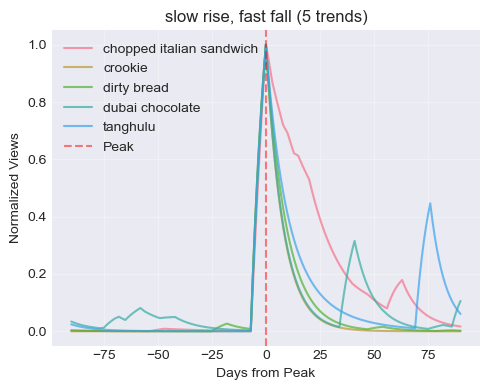

In [27]:
# plotting code
shapes = features_df['shape_classification'].unique()
n_shapes = len(shapes)

fig, axes = plt.subplots(1, n_shapes, figsize=(5 * n_shapes, 4))

# If there is only one shape, axes is a single Axes, so wrap it in a list
if n_shapes == 1:
    axes = [axes]

for idx, shape in enumerate(shapes):
    ax = axes[idx]
    trends_in_shape = features_df[features_df['shape_classification'] == shape]['trend_name'].values
    
    print(f"Shape '{shape}': {len(trends_in_shape)} trends")  # DEBUG
    
    for trend in trends_in_shape:
        trend_data = daily_df[daily_df['trend_name'] == trend].copy()
        print(f"  - Processing {trend}: {len(trend_data)} rows")  # DEBUG
        
        peak = trend_data['views_smooth_7d'].max()
        if peak > 0 and len(trend_data) > 0:
            trend_data['normalized'] = trend_data['views_smooth_7d'] / peak
            
            # Find peak date SAFELY
            try:
                peak_date = pd.to_datetime(
                    peaks_df[peaks_df['trend_name'] == trend]['peak_date'].iloc[0]
                )
                trend_data['days_from_peak'] = (trend_data['date'] - peak_date).dt.days
            except (IndexError, KeyError):
                print(f"    - No peak_date found for {trend}, skipping")
                continue
            
            # FIXED: use trend_data, not plot_data
            plot_data = trend_data[trend_data['days_from_peak'].abs() <= 90]
            if len(plot_data) > 0:
                ax.plot(plot_data['days_from_peak'], plot_data['normalized'], 
                        alpha=0.7, linewidth=1.5, label=trend)
            else:
                print(f"    - No data within ±90 days for {trend}")

    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Peak')
    ax.set_title(f"{shape} ({len(trends_in_shape)} trends)")
    ax.set_xlabel('Days from Peak')
    ax.set_ylabel('Normalized Views')
    ax.grid(True, alpha=0.3)
    if len(trends_in_shape) <= 5:  # Only show legend if few trends
        ax.legend()

plt.tight_layout()
plt.savefig('Time Series Analysis of Youtube Food Virality/data/figures/shape_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. What Makes a Trend Go Viral? (Tag Analysis)

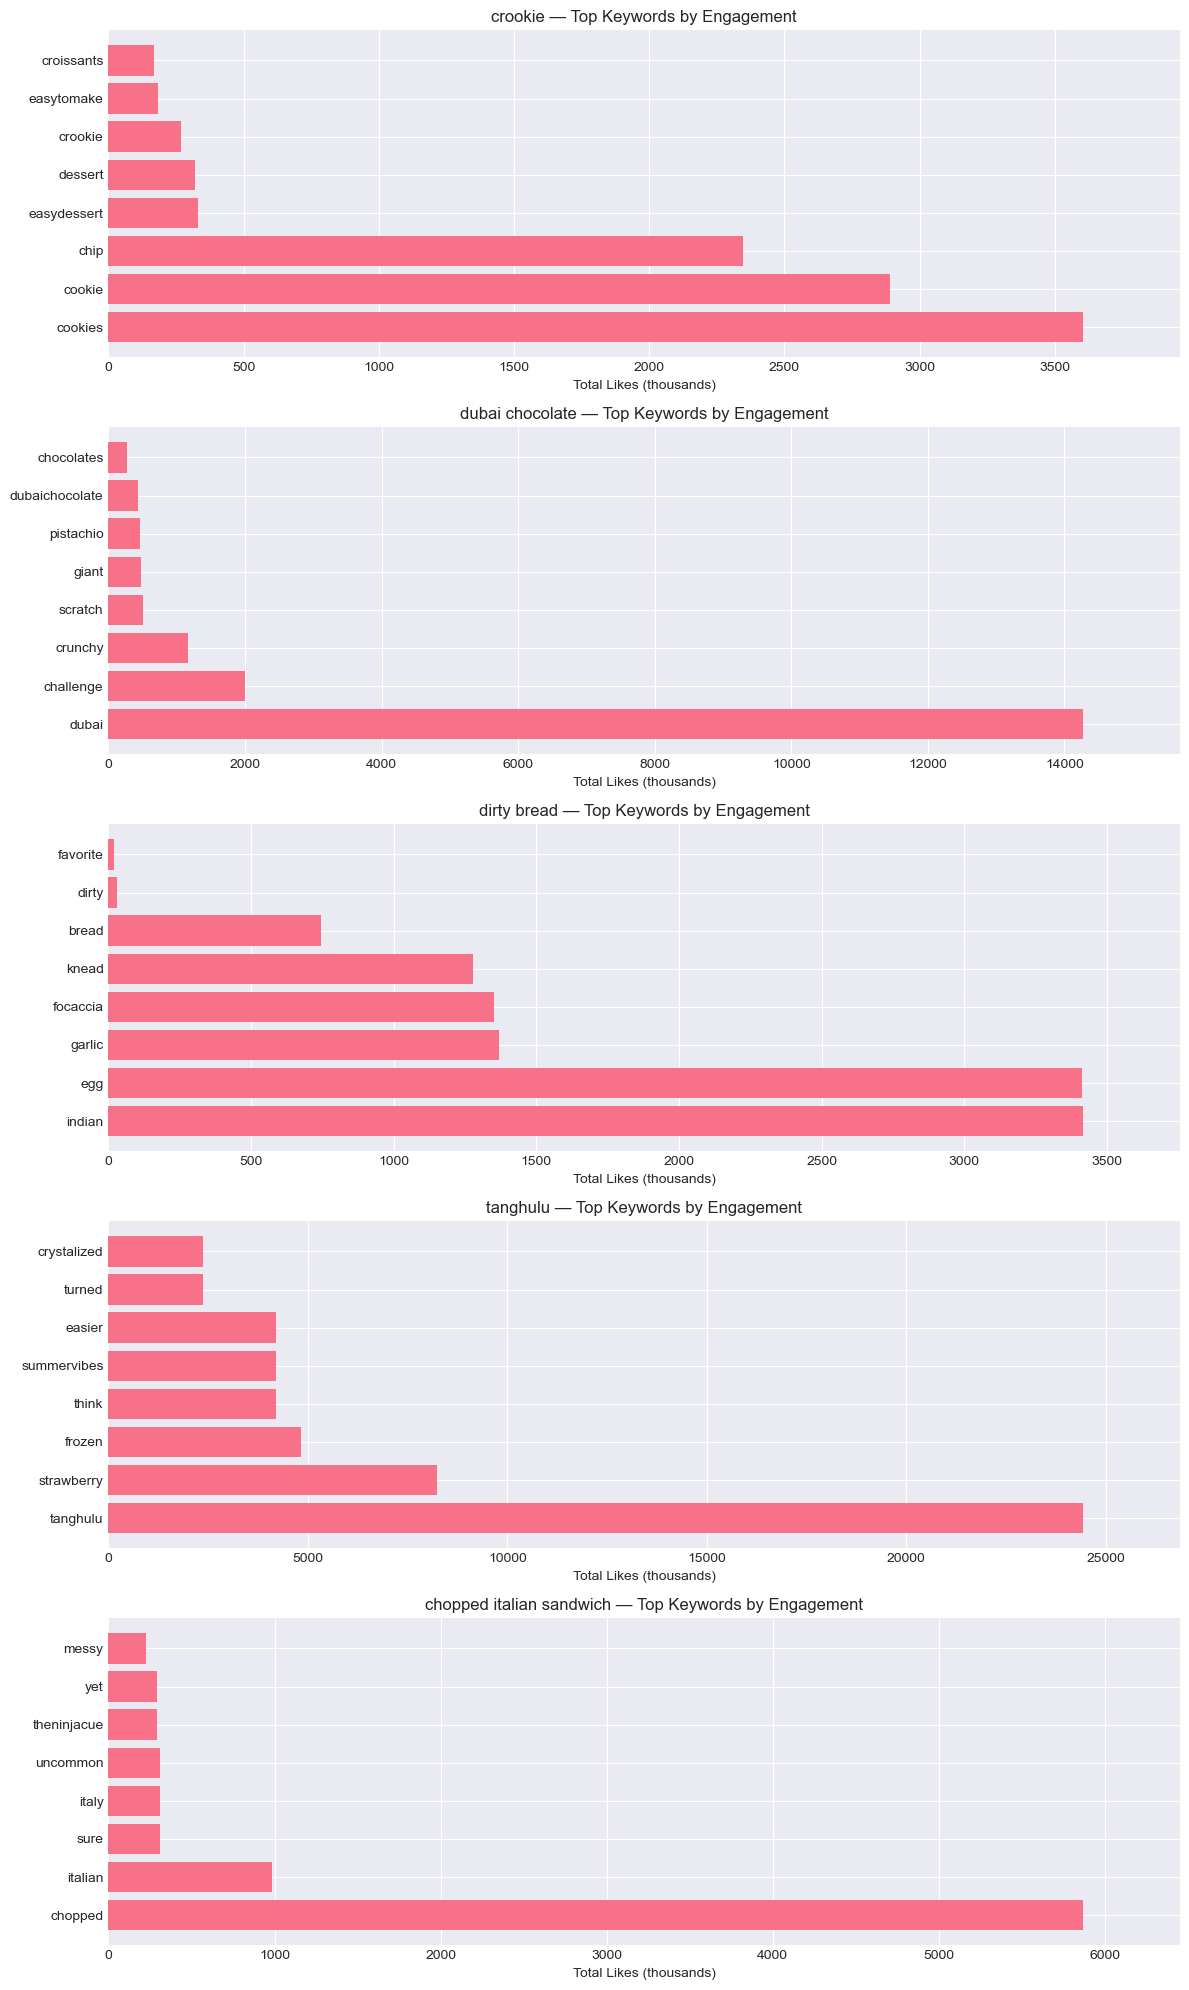

In [39]:
kw_df = pd.read_csv('Time Series Analysis of Youtube Food Virality/data/processed/keyword_impact.csv')

# Only trend-specific keywords
specific = kw_df[kw_df['trend_count'] == 1].copy()

trends = specific['trend'].unique() if 'trend' in specific.columns else specific.groupby('keyword')

# Since trend isn't stored per-keyword, re-derive it from the raw data
raw_df = pd.read_csv('Time Series Analysis of Youtube Food Virality/data/raw/all_trends_complete.csv')

import re
STOPWORDS = {
    'a','an','the','and','or','in','on','at','to','for','of','is','it','its',
    'this','that','with','how','make','making','made','i','my','you','your',
    'me','we','our','are','was','be','do','did','get','got','can','will',
    'video','youtube','shorts','viral','food','recipe','recipes','cooking',
    'cook','cooked','trying','tried','try','eat','eating','ate','taste',
    'tasting','watch','new','best','good','real','just','so','the','what',
    'more','all','its','but','not','have','has','from','out','one','top',
    'first','last','ever'
}

# Build keyword->trend mapping
rows = []
for _, row in raw_df.iterrows():
    tokens = re.findall(r"[a-z]{3,}", str(row['title']).lower())
    for kw in set(t for t in tokens if t not in STOPWORDS):
        rows.append({'keyword': kw, 'trend': row['trend_name'],
                     'like_count': row['like_count'], 'comment_count': row['comment_count']})

kw_raw = pd.DataFrame(rows)

# Merge trend info into kw_df
kw_with_trend = kw_raw.merge(specific[['keyword','peak_views','half_life','frequency']], 
                               on='keyword', how='inner')

# Plot top 8 keywords per trend
trends = kw_with_trend['trend'].unique()
fig, axes = plt.subplots(len(trends), 1, figsize=(12, 4 * len(trends)))

for i, trend in enumerate(trends):
    trend_kws = (kw_with_trend[kw_with_trend['trend'] == trend]
                 .groupby('keyword')
                 .agg({'peak_views': 'mean', 'half_life': 'mean', 'like_count': 'sum'})
                 .sort_values('like_count', ascending=False)
                 .head(8))
    
    axes[i].barh(range(len(trend_kws)), trend_kws['like_count'].values / 1e3)
    axes[i].set_yticks(range(len(trend_kws)))
    axes[i].set_yticklabels(trend_kws.index)
    axes[i].set_xlabel('Total Likes (thousands)')
    axes[i].set_title(f'{trend} — Top Keywords by Engagement')
    axes[i].set_xlim(0, (trend_kws['like_count'].values / 1e3).max() * 1.1)

plt.tight_layout()
plt.savefig('Time Series Analysis of Youtube Food Virality/data/figures/keyword_impact.png', 
            dpi=300, bbox_inches='tight')
plt.show()

## 4. Engagement Analysis

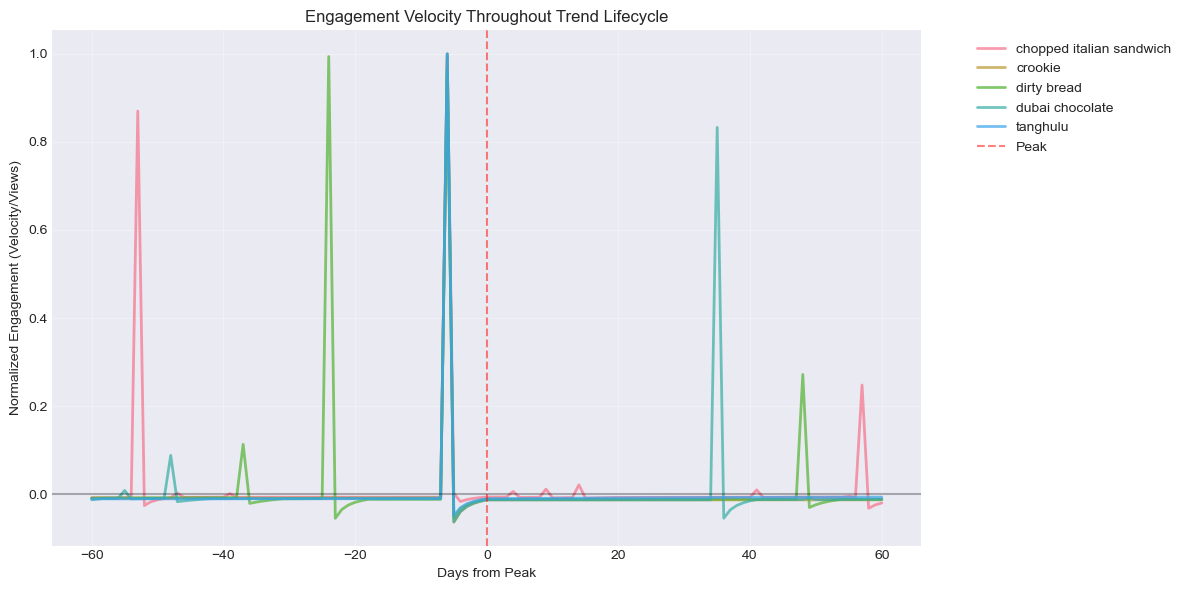

In [41]:
# Calculate engagement metrics
daily_with_velocity = daily_df.copy()
daily_with_velocity['engagement_views_ratio'] = daily_df['views_velocity'] / daily_df['views_smooth_7d']
daily_with_velocity['engagement_views_ratio'] = daily_with_velocity['engagement_views_ratio'].replace([np.inf, -np.inf], np.nan)

# Plot engagement over lifecycle
fig, ax = plt.subplots(figsize=(12, 6))

for trend in daily_with_velocity['trend_name'].unique():
    trend_data = daily_with_velocity[daily_with_velocity['trend_name'] == trend].copy()
    peak_date = peaks_df[peaks_df['trend_name'] == trend]['peak_date'].values[0]
    trend_data['days_from_peak'] = (trend_data['date'] - pd.to_datetime(peak_date)).dt.days
    
    # Normalize engagement for comparison
    engagement_clean = trend_data['engagement_views_ratio'].dropna()
    if len(engagement_clean) > 0:
        trend_data.loc[engagement_clean.index, 'engagement_norm'] = (
            engagement_clean / engagement_clean.abs().max()
        )
        
        plot_data = trend_data[abs(trend_data['days_from_peak']) <= 60]
        ax.plot(plot_data['days_from_peak'], plot_data['engagement_norm'], 
               alpha=0.7, linewidth=2, label=trend)

ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Peak')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Days from Peak')
ax.set_ylabel('Normalized Engagement (Velocity/Views)')
ax.set_title('Engagement Velocity Throughout Trend Lifecycle')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Time Series Analysis of Youtube Food Virality/data/figures/engagement_lifecycle.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Key Findings & Conclusions

In [44]:
# Summary statistics
print("="*60)
print("📈 VIRAL COOKING TRENDS: KEY FINDINGS")
print("="*60)

# Fastest rise
fastest_rise = features_df.loc[features_df['days_to_peak'].idxmin()]
print(f"\n⚡ Fastest to Peak: {fastest_rise['trend_name']}")
print(f"   - Reached peak in {fastest_rise['days_to_peak']:.0f} days")
print(f"   - Peak intensity: {fastest_rise['peak_intensity']:.1f}x average")

# Longest lasting
longest_half = features_df.loc[features_df['half_life_days'].idxmax()]
print(f"\n🐢 Longest Lasting: {longest_half['trend_name']}")
print(f"   - Half-life: {longest_half['half_life_days']:.0f} days")
print(f"   - Total days active: {longest_half['days_to_peak'] + longest_half['half_life_days']:.0f}")

# Most intense
most_intense = features_df.loc[features_df['peak_intensity'].idxmax()]
print(f"\n🔥 Most Intense Peak: {most_intense['trend_name']}")
print(f"   - Peak was {most_intense['peak_intensity']:.1f}x average daily views")
print(f"   - Total views: {most_intense['total_views']/1e6:.1f}M")

# Most engaging
most_engaging = features_df.loc[features_df['engagement_rate'].idxmax()]
print(f"\n❤️ Most Engaging: {most_engaging['trend_name']}")
print(f"   - Engagement rate: {most_engaging['engagement_rate']:.4f}")
print(f"   - Avg likes/video: {most_engaging['avg_likes_per_video']:.0f}")

# Pattern summary
print(f"\n📊 Pattern Distribution:")
for shape in features_df['shape_classification'].value_counts().index:
    count = features_df['shape_classification'].value_counts()[shape]
    pct = count / len(features_df) * 100
    print(f"   - {shape}: {count} trends ({pct:.0f}%)")

# Save final report
with open('Time Series Analysis of Youtube Food Virality/reports/final_analysis.md', 'w') as f:
    f.write("# Viral Cooking Trends Analysis\n\n")
    f.write("## Key Metrics\n\n")
    f.write(f"- **Trends Analyzed:** {len(features_df)}\n")
    f.write(f"- **Total Videos:** {len(raw_df)}\n")
    f.write(f"- **Date Range:** {daily_df['date'].min().date()} to {daily_df['date'].max().date()}\n\n")
    
    f.write("## Top Findings\n\n")
    f.write(f"1. **Fastest to Peak:** {fastest_rise['trend_name']} ({fastest_rise['days_to_peak']} days)\n")
    f.write(f"2. **Longest Lasting:** {longest_half['trend_name']} ({longest_half['half_life_days']} days half-life)\n")
    f.write(f"3. **Most Intense:** {most_intense['trend_name']}\n\n")
    
    f.write("## Recommendations\n\n")
    f.write("- For quick virality, focus on tags that drive rapid growth\n")
    f.write("- For sustained trends, emphasize community-building content\n")
    f.write("- Peak engagement happens BEFORE peak views—strike while interest is high\n")

print("\n✅ Analysis complete! Check 'reports/final_analysis.md' for summary")

📈 VIRAL COOKING TRENDS: KEY FINDINGS

⚡ Fastest to Peak: dubai chocolate
   - Reached peak in 150 days
   - Peak intensity: 10.9x average

🐢 Longest Lasting: chopped italian sandwich
   - Half-life: 21 days
   - Total days active: 334

🔥 Most Intense Peak: dirty bread
   - Peak was 158.1x average daily views
   - Total views: 240.2M

❤️ Most Engaging: crookie
   - Engagement rate: 1.7694
   - Avg likes/video: 99915

📊 Pattern Distribution:
   - slow rise, fast fall: 5 trends (100%)

✅ Analysis complete! Check 'reports/final_analysis.md' for summary
